# Предпочтительное присоединение

Вспомним модель Барабаши-Альберт:

1) роста сети (каждую итерацию добавляется новая вершина с $m$ ребрами)

2) предпочтительном присоединении (вероятность связывания со старой вершиной пропорциональна ее степени)

Распределение степеней подчиняется степенному закону $P(k)=Ck^{-\gamma}$, $\gamma=3$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import gdown

Включаем отображение графиков прямо в ноутбуке

In [2]:
%matplotlib inline

Параметры `n` - число вершин (10000) и `m` - число шагов (10) определяют плотность сети. Надо логировать параметр m, чтобы добиться определенной плотности графа.

In [3]:
ba = nx.barabasi_albert_graph(10000,10)

print ('Number of edges =',ba.number_of_edges())
degrees = [d for node, d in ba.degree()]
print ('Average degree =',np.mean(degrees))

Number of edges = 99900
Average degree = 19.98


Если построить распределение степеней, то мы получим степенной закон - хорошая прямая линия. По оси x - огарифмическая шкала степеней, по оси y - кумулятивное распределение (та величина, которую  считали аналитически).

In [4]:
!pip install powerlaw
import powerlaw

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.0/192.0 kB 3.4 MB/s eta 0:00:00


Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 171/171 [00:00<00:00, 929.28it/s] 

2.8726497127966755
11.0


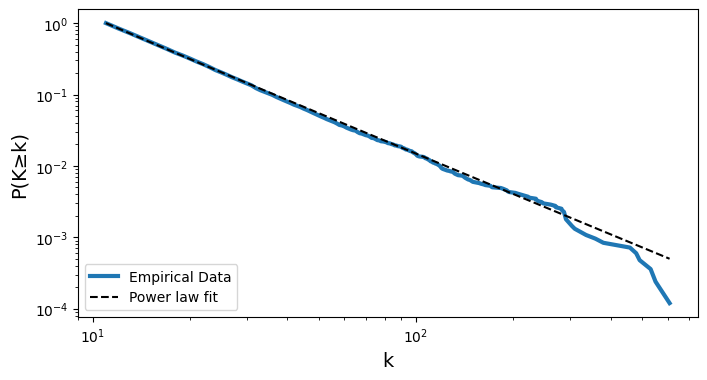

In [5]:
fig, ax = plt.subplots(figsize=(8,4))

fit = powerlaw.Fit(degrees, discrete=True)

#fit.distribution_compare('lognormal', 'truncated_power_law')
fit.plot_ccdf(ax=ax, linewidth=3, label='Empirical Data')
fit.power_law.plot_ccdf(ax=ax, color='k', linestyle='--', label='Power law fit')

ax.set_ylabel(u"P(K≥k)",fontsize=14)
ax.set_xlabel("k",fontsize=14)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc=3,fontsize=10)

print(fit.power_law.alpha)
print(fit.power_law.xmin)

Для малых степеней статистика хорошая, а там, где хабы, из-за конечности системы статистика немного едет от прямой линии. Это статистика для одной реализации, но если мы наберем  статистику по нескольким реализациям, то все будет попроще.  

Как будут себя вести такие параметры, как диаметр и кластеризация в модели Барабаши-Альберт? Строгих выводов нет, но оценки, не столь важны, так как диаметры и среднее расстояние зависят от размера системы. Многие дефекты можно объяснить тем, что у нас есть хабы или вершины высоких степеней, которые удерживают сеть в высокосвязанном состоянии.

In [6]:
# print(f"Диаметр: {nx.diameter(ba)}")
# print(f"Кластеризация: {nx.average_clustering(ba)}")

## 1. Рост сети цитирований (6 баллов)

Для данных известно время появления каждой вершины (статьи). Рассмотрим рост сети цитирований, считая за единицу времени 1 месяц, т.е. за один шаг к существующей сети добавляются вершины одного месяца, далее - следующего и т.д.

* Постройте зависимость степени вершины от времени для нескольких "старых" вершин. Какому закону подчиняется рост сети?

* Вычислите прирост степени $i$-ой вершины за единицу времени $\Delta k_i$ для каждой текущей вершины $i$ времени $t$ как изменение степени за 1 месяц.
Определите суммарное изменение степеней вершин $\pi (k)=\sum_{k_i}\Delta k_i$ (кумулятивное распределение прироста степени) и $k=max (k_i)$ (по значениям начального месяца).

* Постройте зависимость $\pi (k)$ и аппроксимируйте ее степенной функцией. Можно ли считать, что сеть растет по принципу предпочтительного присоединения? Определите тип присоединения.

Есть довольно большая сеть цитирований на объеме ребер n и E. Есть динамика сети, которая представляет собой лист того, когда появилась некоторая вершина (столбец 1 - номер вершины, столбец 2 - дата, когда эта вершина появилась в сети). Берем фиксированную дату и смотрим, сколько вершин из сети были на тот момент. Выбираем из графа подграф на этом множестве вершин - это и есть та сеть, которую мы видели на тот момент времени.

Для понимания того, что представляют из себя данные, можно построить зависимости того, как растет от времени число вершин и ребер (не факт, что линейно, как в модели Барабаши-Альберт).

Основная задача - измерить предпочтительное присоединение в реальных сетях. Строим последовательность графов, где каждый следующий отличается некоторым $∆t$, равным 1 месяцу. Как выяснить, есть ли предпочтительное присоединение между двумя соседними шагами? Если оно есть, то степень $∆k_i / ∆t$ растет пропорционально степени $i$-той вершины. Так как $∆t$ равно 1 месяцу, то надо показать, что $∆k_i$ пропорционально $k_i$-той степени.

Надо построить график изменения степени $∆k_i$ в зависимости от степени вершин. Но так как вершин много, то по этой зависимости тяжело что-то понять. Первый шаг - сгруппировать вершины по значению степени и нарисовать график, где по оси х - значение степени $k$, а по оси y - среднее значение изменения степени для вершин, у которых степень $k$. Надо иметь в виду, что $k$ относится к графу, на который мы сейчас смотрим, а изменение строится по разнице двух графов. Если зависимость хорошо ложится на линейный график, то делаем вывод о наличии предпочтительного присоединения.

Если никакого предпочтительного присоединения нет, то от степени ничего зависеть не будет. Мы будем в лучшем случае видеть осцилляции или нетипичную для предпочтительного присоединения зависимость.

Нарисовать зависимости для всех графов по месяцам на одном графике. Но даже в такой зависимости статистики может не хватить или линейную зависимость будет тяжело увидеть. Поэтому часто смотрят на **кумулятивное распределение** - не будем разделять вершины по степеням, а просуммируем все вершины. Берем $K = max(k_i)$ и суммируем приращения для всех вершин. Приращение всех степеней от одного шага до другого есть удвоенное число ребер. Берем две соседние конфигурации и смотрим, как изменилось число ребер и какая была максимальная степень $k_i$. Это и дает точку в зависимости $k$ и $П(k)$. Если есть предпочтительное присоединение, то зависимость должна быть равна $k^2$. Если рост сети случайный, то должна быть линейность.

## Загружаем сеть
`!gdown` у меня недоступен как системная команда в оболочке zsh, которую  юпитер ноутбук использует для выполнения команд с !.
Вместо этого используем Python API библиотеку gdown напрямую через `gdown.download()`, так как он работает в том же Python-окружении, что и весь ноутбук и не зависит от системных путей и настроек оболочки

In [7]:
file_id = "1vIbbqxDx7Y1nYfE8pAx-eLtbhSokSu6V"
url = f"https://drive.google.com/uc?id={file_id}"
output = "Cit-HepPh.txt"

gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1vIbbqxDx7Y1nYfE8pAx-eLtbhSokSu6V
To: /content/Cit-HepPh.txt
100%|██████████| 6.70M/6.70M [00:00<00:00, 86.0MB/s]


'Cit-HepPh.txt'

Выводим основные свойства графа:
- количество вершин
- количество ребер
- плотность сети

In [8]:
G = nx.read_edgelist("Cit-HepPh.txt",nodetype=int)

print('Nodes:', G.number_of_nodes())
print('Edges:', G.number_of_edges())
print('Density:', nx.density(G))

Nodes: 34546
Edges: 420921
Density: 0.0007054197642773696


## Загружаем даты появления вершин
Повторяем аналогично через `gdown.download()`

In [9]:
file_id_spreading = "1G4SOy6ltn_gwiSOCUiZ5ZBrEeA0p0y77"
url = f"https://drive.google.com/uc?id={file_id_spreading}"
output = "cit-HepPh-dates.txt"

gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1G4SOy6ltn_gwiSOCUiZ5ZBrEeA0p0y77
To: /content/cit-HepPh-dates.txt
100%|██████████| 781k/781k [00:00<00:00, 38.4MB/s]


'cit-HepPh-dates.txt'

Записываем данные в дата-фрейм и даем названия столбцам для удобства работы с ними

In [10]:
data = pd.read_csv('cit-HepPh-dates.txt', sep='\t', names=['id', 'date'])
data.head(5)

,id,date
0,# cross-listed papers have ids 11<true_id>,NaN
1,9203201,1992-02-24
2,9203202,1992-03-08
3,9203203,1992-03-03
4,9203204,1992-03-09


Удаляем первую строку с дополнительной информацией

In [11]:
data = data.iloc[1:]

Приводим типы данных в датафрейме к числу и дате

In [12]:
data.dtypes

,0
id,object
date,object


In [13]:
data['id'] = data['id'].astype(int)
data['date'] = pd.to_datetime(data['date'])

В файле с датами статей больше чем в графе - убираем ту часть статей, которые не участвуют в цитировании

In [14]:
data.shape

(38557, 2)

In [15]:
data = data[data['id'].isin(G.nodes())]

In [16]:
print("Кол-во статей в графе:", G.number_of_nodes())
print("Кол-во статей с датами:", len(data))

Кол-во статей в графе: 34546
Кол-во статей с датами: 30696


Сортируем список вершин по дате их появления в сети

In [17]:
data = data.sort_values('date')

Выбираем "старые" вершины - берем первые 5 строк из отсортированной таблицы

In [18]:
old_nodes = data.head(5)['id'].values
print("Старые вершины:", old_nodes)

degree_evolution = {node: [] for node in old_nodes}

Старые вершины: [9211202 9203201 9203203 9203202 9203206]


Составляем список месяцев

In [19]:
months = pd.date_range(
    start=data['date'].min(),
    end=data['date'].max(),
    freq='MS'
)
print("Количество месяцев:", len(months))

Количество месяцев: 121


Строим график динамики степеней "старых" вершин в зависимости от времени

In [20]:
for month in months:
    nodes_month = data[data['date'] <= month]['id'].values

    sub = G.subgraph(nodes_month)

    for node in old_nodes:
        if node in sub:
            degree_evolution[node].append(sub.degree(node))
        else:
            degree_evolution[node].append(0)

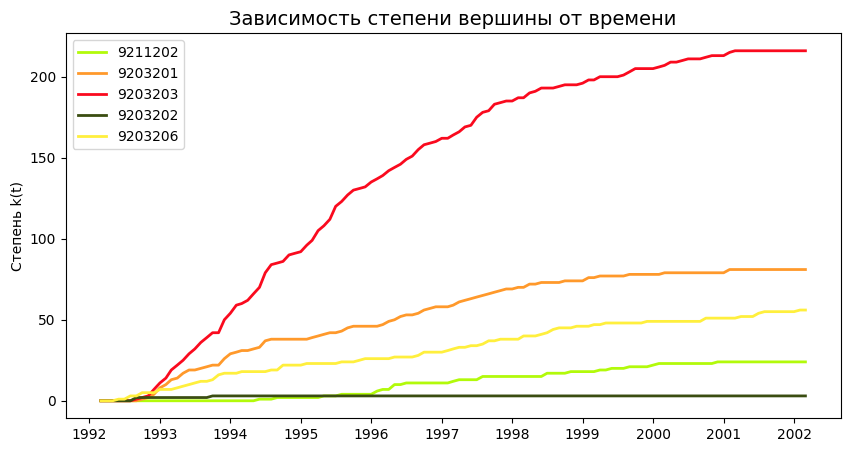

In [21]:
colors = ['#b2fa0a', '#ff992b', '#fa0a1e', '#3a4d11', '#ffef3d']
plt.figure(figsize=(10,5))

for i, node in enumerate(old_nodes):
    plt.plot(
        months,
        degree_evolution[node],
        color=colors[i],
        linewidth=2,
        label=f'{node}'
    )

plt.title("Зависимость степени вершины от времени", fontsize=14)
plt.ylabel("Степень k(t)")
plt.legend()
plt.show()

### Вывод
По графику видно, что степени вершин растут с разной скоростью:
- вершина 9203203 растет быстрее всех, значит она более цитируема, и новые статьи чаще ссылаются на нее
- вершина 9211202 почти горизонтальна, то есть она мало цитируема, и ее степень растет медленно

Такая зависимость согласуется с моделью линейного предпочтительного присоединения: вершины с большой степенью (часто цитируемые статьи) продолжают получать больше новых связей со временем, а вершины с маленькой степенью растут медленно.

Считаем прирост степени для всех вершин по месяцам

In [22]:
all_nodes = G.nodes()
degree_over_time = {node: [] for node in all_nodes}

for month in months:
    nodes_month = data[data['date'] <= month]['id'].values
    sub = G.subgraph(nodes_month)
    for node in all_nodes:
        if node in sub:
            degree_over_time[node].append(sub.degree(node))
        else:
            degree_over_time[node].append(0)

Считаем приращение степени для каждого узла и суммируем по степеням

In [23]:
delta_k_list = []
for i in range(1, len(months)):
    delta_k = {}
    for node in all_nodes:
        k_prev = degree_over_time[node][i-1]
        k_curr = degree_over_time[node][i]
        dk = k_curr - k_prev
        if dk > 0:
            delta_k[k_prev] = delta_k.get(k_prev, 0) + dk
    delta_k_list.append(delta_k)

In [24]:
pi_k = {}
for dk in delta_k_list:
    for k, val in dk.items():
        pi_k[k] = pi_k.get(k, 0) + val

Подготавливаем данные для логарифмического графика

In [25]:
k_vals = np.array(list(pi_k.keys()))
pi_vals = np.array(list(pi_k.values()))

In [26]:
print("Максимальная степень:", np.max(k_vals))
print("Минимальная степень:", np.min(k_vals))
print("Количество различных значений k:", len(k_vals))

Максимальная степень: 643
Минимальная степень: 0
Количество различных значений k: 476


In [27]:
sorted_indices = np.argsort(k_vals)
k_vals = k_vals[sorted_indices]
pi_vals = pi_vals[sorted_indices]

In [28]:
mask = k_vals > 0
k_vals_nonzero = k_vals[mask]
pi_vals_nonzero = pi_vals[mask]

В модели Барабаши–Альберт вероятность присоединения новой вершины к существующей пропорциональна её степени. Это приводит к степенному распределению степеней: $P(k)$ ~ $k^{-α}$. Показатель α характеризует структуру сети и наличие «хабов».

In [29]:
log_k = np.log10(k_vals_nonzero)
log_pi = np.log10(pi_vals_nonzero)

coeffs = np.polyfit(log_k, log_pi, 1)
alpha = coeffs[0]

print(f"Приближенный α = {alpha:.2f}")

Приближенный α = -2.04


### Вывод
Аппроксимация логарифмической зависимости дала показатель α ≈ −2.04.
Это означает, что кумулятивный прирост степени убывает по степенному закону. Отрицательный показатель указывает на ослабление эффекта предпочтительного присоединения для вершин с большой степенью, что может быть связано с насыщением сети или ограниченностью цитируемости статей.

Строим логарифмический график кумулятивного распределения π(k)

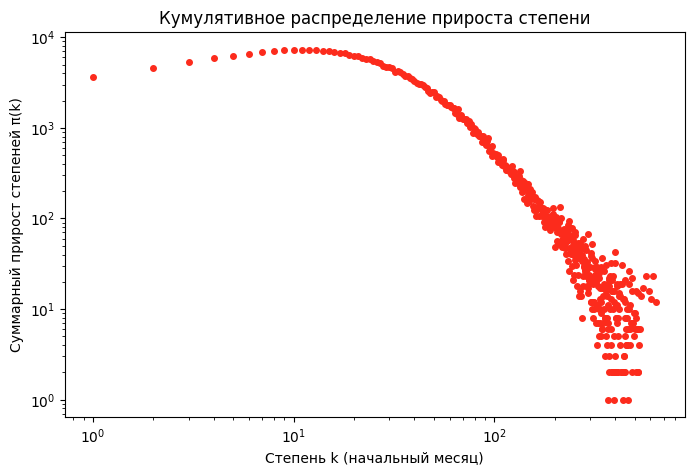

In [30]:
plt.figure(figsize=(8,5))
plt.plot(k_vals_nonzero, pi_vals_nonzero, 'o',
         color='#fc2b1c', markersize=4)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Степень k (начальный месяц)')
plt.ylabel('Суммарный прирост степеней π(k)')
plt.title('Кумулятивное распределение прироста степени')

plt.show()

### Вывод
На графике наблюдается степенной участок в области малых и средних степеней. В начальной части графика точки располагаются почти по прямой линии, что свидетельствует о наличии степенной зависимости между приростом степени и самой степенью вершины.
Однако в области больших степеней зависимость начинает отклоняться от прямой и формирует дугообразный изгиб, а точки становятся более разбросанными. Это указывает на отклонение от идеальной модели линейного предпочтительного присоединения.

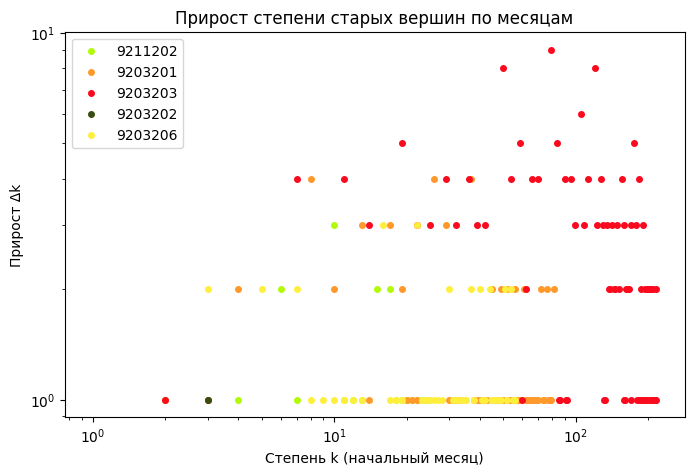

In [31]:
colors = ['#b2fa0a', '#ff992b', '#fa0a1e', '#3a4d11', '#ffef3d']

plt.figure(figsize=(8,5))

for i, node in enumerate(old_nodes):
    k_node = np.array([degree_evolution[node][j]
                       for j in range(len(months))
                       if degree_evolution[node][j] > 0])

    delta_node = np.diff(k_node, prepend=k_node[0])

    mask_node = k_node > 0

    plt.plot(k_node[mask_node],
             delta_node[mask_node],
             'o',
             color=colors[i],
             markersize=4,
             label=f'{node}')

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Степень k (начальный месяц)')
plt.ylabel('Прирост Δk')
plt.title('Прирост степени старых вершин по месяцам')
plt.legend()
plt.show()

### Вывод
Точки старых вершин формируют несколько почти линейных зависимостей.
Вершина 9203203 демонстрирует наибольший прирост степени. Часть её значений хаотично разбросана в правом верхнем углу графика, что свидетельствует о неравномерном росте цитируемости на поздних этапах.

Объединяем два графика вместе

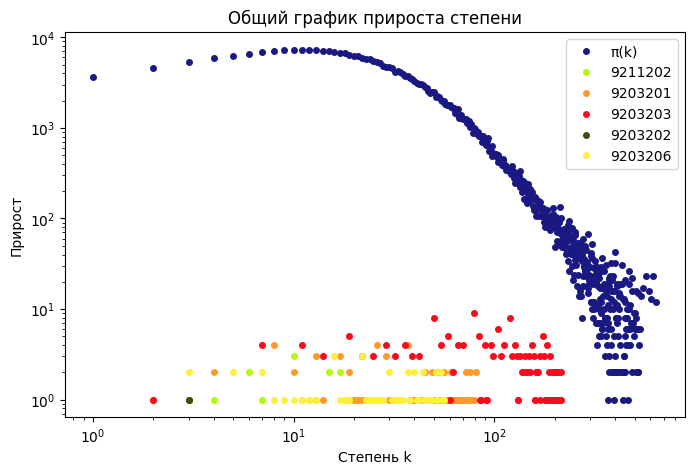

In [32]:
plt.figure(figsize=(8,5))

# π(k)
plt.plot(k_vals_nonzero, pi_vals_nonzero,
         'o',
         color='#1a1982',
         markersize=4,
         label='π(k)')

# старые вершины
for i, node in enumerate(old_nodes):
    k_node = np.array([degree_evolution[node][j]
                       for j in range(len(months))
                       if degree_evolution[node][j] > 0])

    delta_node = np.diff(k_node, prepend=k_node[0])

    mask_node = k_node > 0

    plt.plot(k_node[mask_node],
             delta_node[mask_node],
             'o',
             color=colors[i],
             markersize=4,
             label=f'{node}')

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Степень k')
plt.ylabel('Прирост')
plt.title('Общий график прироста степени')

plt.legend()
plt.show()

### Вывод
В представленной сети цитирований наблюдается частичное проявление механизма предпочтительного присоединения: вершины с большей степенью получают больший прирост связей.
Однако зависимость не является строго линейной на всём диапазоне степеней.
Для больших значений степени наблюдается отклонение от степенного закона, что говорит о более сложной динамике роста по сравнению с классической моделью Барабаши-Альберт.

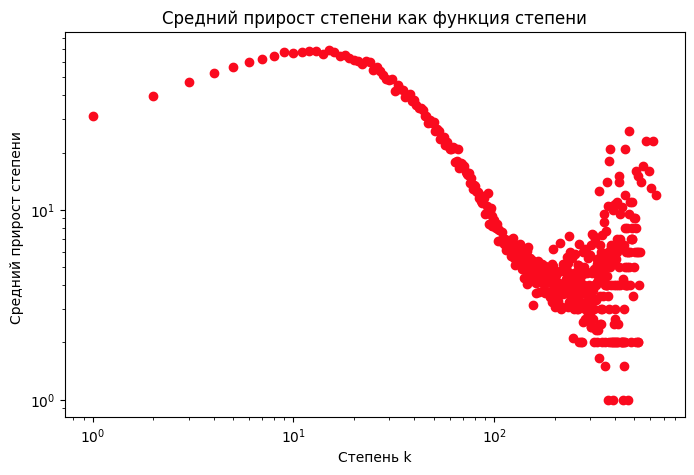

In [33]:
avg_delta = {}

for dk_dict in delta_k_list:
    for k, val in dk_dict.items():
        if k not in avg_delta:
            avg_delta[k] = []
        avg_delta[k].append(val)

k_avg = []
delta_avg = []

for k in sorted(avg_delta.keys()):
    k_avg.append(k)
    delta_avg.append(np.mean(avg_delta[k]))

k_avg = np.array(k_avg)
delta_avg = np.array(delta_avg)

mask = k_avg > 0

plt.figure(figsize=(8,5))
plt.plot(k_avg[mask], delta_avg[mask], 'o', color='#fa0a1e')

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Степень k")
plt.ylabel("Средний прирост степени ")
plt.title("Средний прирост степени как функция степени")
plt.show()

### Вывод
На графике зависимости среднего прироста степени от текущей степени k наблюдаются три характерных режима:
- При малых степенях (k < 10) точки выстраиваются в возрастающую зависимость. Это указывает на наличие механизма предпочтительного присоединения: вершины с большей степенью получают больший прирост связей.
- В диапазоне степеней от 10 до 100 зависимость приобретает форму выпуклой дуги, при этом средний прирост начинает снижаться. Это свидетельствует об отклонении от строго линейного предпочтительного присоединения.
- При больших степенях (k > 100) точки распределяются более хаотично. С ростом степени заметно увеличивается разброс значений ⟨Δk⟩ относительно общей тенденции.
Разброс значений при больших k можно объяснить малым числом вершин с большой степенью, высокой чувствительностью к единичным изменениям и колебаниями в динамике цитирования.

В модели Барабаши-Альберт механизм роста исследуется через зависимость среднего прироста степени $⟨Δk⟩$ ~ $k^ß$. Показатель β определяет тип предпочтительного присоединения.

In [34]:
log_k_avg = np.log10(k_avg[mask])
log_delta_avg = np.log10(delta_avg[mask])

coeffs_beta = np.polyfit(log_k_avg, log_delta_avg, 1)
beta = coeffs_beta[0]

print(f"Показатель присоединения β = {beta:.2f}")

Показатель присоединения β = -0.69


### Вывод
Отрицательное значение параметра $ß$ свидетельствует о наличии обратной зависимости, при которой крупные вершины растут медленнее. Таким образом, в исследуемой сети отсутствует механизм линейного предпочтительного присоединения. Напротив, наблюдается ослабление прироста для вершин большой степени.
Это говорит о том, что рост сети не соответствует классической модели Барабаши–Альберт и определяется более сложными динамическими механизмами.

В качестве дополнительной проверки динамики сети вычислим для каждого месяца число ребер и вершин

In [35]:
N_t = []
E_t = []
avg_k = []

data['month'] = data['date'].dt.to_period('M')
months = sorted(data['month'].unique())

current_nodes = set()

for month in months:
    new_nodes = set(data[data['month'] == month]['id'])
    current_nodes.update(new_nodes)

    subG = G.subgraph(current_nodes)

    N = subG.number_of_nodes()
    E = subG.number_of_edges()

    N_t.append(N)
    E_t.append(E)

    if N > 0:
        avg_k.append(2 * E / N)
    else:
        avg_k.append(0)

months_plot = [m.to_timestamp() for m in months]

Построим графики зависимости количества ребер и вершин, а также степеней от времени

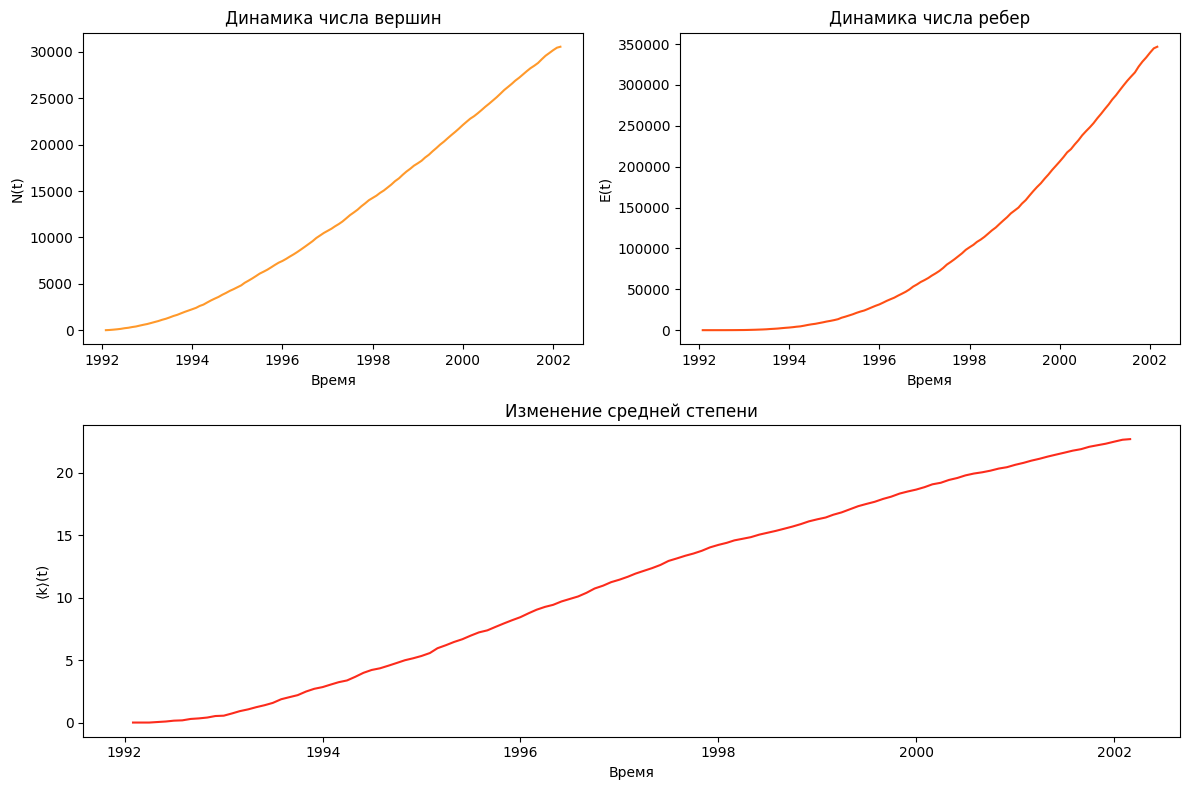

In [36]:
colors = ['#ff992b', '#ff4f14', '#fc2b1c']
fig = plt.figure(figsize=(12,8))

# Число вершин
ax1 = plt.subplot(2,2,1)
ax1.plot(months_plot, N_t, color=colors[0])
ax1.set_xlabel("Время")
ax1.set_ylabel("N(t)")
ax1.set_title("Динамика числа вершин")

# Число рёбер
ax2 = plt.subplot(2,2,2)
ax2.plot(months_plot, E_t, color=colors[1])
ax2.set_xlabel("Время")
ax2.set_ylabel("E(t)")
ax2.set_title("Динамика числа ребер")

# Средняя степень
ax3 = plt.subplot(2,1,2)
ax3.plot(months_plot, avg_k, color=colors[2])
ax3.set_xlabel("Время")
ax3.set_ylabel("⟨k⟩(t)")
ax3.set_title("Изменение средней степени")

plt.tight_layout()
plt.show()

### Вывод
- Число вершин сети во времени демонстрирует близкий к линейному рост.
То есть новые статьи добавляются с приблизительно постоянной скоростью, что соответствует базовому предположению модели Барабаши-Альберт о непрерывном росте сети.
- Рост числа ребер имеет нелинейный характер и демонстрирует ускорение во времени. Кривая выгибается вверх, что свидетельствует о более быстром увеличении числа связей по сравнению с ростом числа вершин. В модели Барабаши-Альберт число ребер растет тоже линейно.
- Возрастание средней степени говорит об уплотнении сети со временем и отклонении от классической модели Барабаши-Альберт, в которой средняя степень остается постоянной.

Сеть эволюционирует иначе, чем BA. Новые связи перераспределяются по сети более равномерно, а не концентрируются в хабах.



Аппроксимируем зависимости $N(t)≈a_N​t+b$ и $E(t)≈a_E​t+c$, где $a_N​$ - скорость добавления вершин, $a_E$ — скорость добавления ребер. Это коэффициенты наклона линейной регрессии.

In [37]:
coeff_N = np.polyfit(range(len(N_t)), N_t, 1)
coeff_E = np.polyfit(range(len(E_t)), E_t, 1)

print("Коэффициент линейного роста вершин:", round(coeff_N[0], 4))
print("Коэффициент линейного роста рёбер:", round(coeff_E[0], 4))
print("Отношение коэффициентов:", round(coeff_E[0] / coeff_N[0], 4))

Коэффициент линейного роста вершин: 268.9303
Коэффициент линейного роста рёбер: 2903.719
Отношение коэффициентов: 10.7973


### Вывод
В модели Барабаши-Альберт добавляется одна вершина за шаг и фиксированное число ребер m. Поэтому $N(t)$ ∼ $t$ и $E(t)$ ∼ $t$, а скорости роста пропорциональны.

Каждый временной шаг добавляется примерно 269 вершин и 2904 ребер, то есть на одну новую вершину приходится в среднем 11 новых ребер. Скорость добавления ребер превышает скорость добавления вершин больше, чем в 10 раз. Это доказывает вывод об интенсивном уплотнении сети и отклонении от классической модели Барабаши-Альберта, где средняя степень остается постоянной.

Построим зависимость числа ребер от числа вершин.

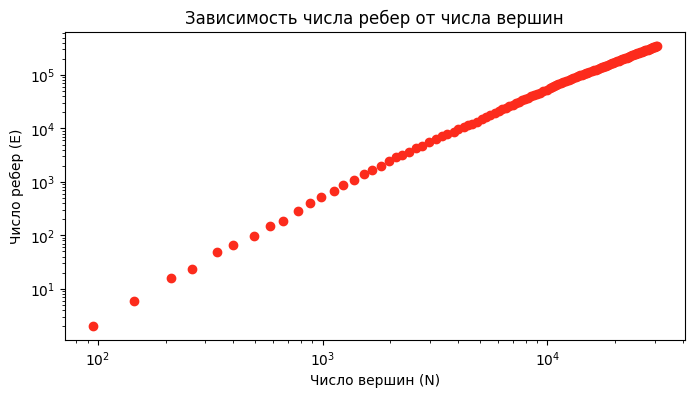

In [38]:
N_arr = np.array(N_t)
E_arr = np.array(E_t)

mask = (N_arr > 0) & (E_arr > 0)

N_nonzero = N_arr[mask]
E_nonzero = E_arr[mask]

plt.figure(figsize=(8,4))
plt.plot(N_nonzero, E_nonzero, 'o', color='#fc2b1c')
plt.xscale('log')
plt.yscale('log')

plt.xlabel("Число вершин (N)")
plt.ylabel("Число ребер (E)")
plt.title("Зависимость числа ребер от числа вершин")

plt.show()

### Вывод
Наблюдается линейный рост зависимости: с ростом количества вершин растет и число ребер в сети.

Построив зависимость числа ребер от числа вершин, мы предполагаем степенную связь: $E(N)$ ~ $N^γ$. Параметр гамма характеризует то, как быстро сеть становится более плотной при росте числа вершин.

In [39]:
log_N = np.log10(N_nonzero)
log_E = np.log10(E_nonzero)

coeffs = np.polyfit(log_N, log_E, 1)
gamma = coeffs[0]

print(f"Показатель уплотнения γ = {gamma:.2f}")

Показатель уплотнения γ = 1.98


### Вывод
Полученное значение γ ~ 2 означает, что сеть очень быстро уплотняется при росте числа вершин. Каждый новый узел подключается к большому числу существующих вершин, а количество ребер растет почти квадратично. Это  отличается от классической модели Барабаши–Альберт, где γ ≈ 1.



## Итоговый вывод
Сеть цитирований не является стационарной разреженной безмасштабной сетью в строгом смысле модели Барабаши–Альберт. Новые вершины добавляются линейно, но количество ребер растет почти квадратично.
Средняя степень увеличивается во времени, что указывает на уплотнение сети. Показатели α и β показывают, что крупные вершины растут медленнее, а прирост степеней распределен более равномерно. Показатель γ подтверждает ускоренное уплотнение сети.

В результате, можно сказать, что сеть развивается по принципу предпочтительного присоединения, но с выраженным уплотнением и ограничением роста хабов. Новые статьи активно цитируют уже существующие, и сеть становится очень плотной со временем.

## 2. Нелинейное предпочтительное присоединение (6 баллов)

* Напишите генератор случайного графа, построенного по принципу нелинейного предпочтительного присоединения:
$$
\Pi(k_i) \sim k_i^{\alpha}
$$
* Постройте зависимость степени вершины (например, выберите одну из затравочных, т.е. с индексом $i=0$) от времени (размера сети) для значений $\alpha=0.5,1.0,2.5$

Рекомендуемые параметры: $m=4, t=[10^2,10^3,10^4,...]$.


* Постройте распределение степеней вершин конечной сети и с помощью powerlaw определите наилучшую аппроксимацию степенным распределением, выведите параметры распределения

В модели Барабаши-Альберт предпочтительное присоединение линейно по степени. Представим, что мы берем не просто $k_i$, а $k_i^{\alpha}$. Можно посчитать аналитически и построить алгоритм, чтобя посмотреть, как работает модель:
- как зависит степень $i$-той вершины от $t$: нарисовать два случая - когда альфа <1 (взять значения 0,5 или 0,7) и >1 (взять значения 2 или 3)
- как зависит $k_i$ от $t$
- какая статистика степеней (сравнить с классической модель Барабаши-Альберт)

Посмотреть на то, как реализована модель Барабаши-Альберт в networkx. Ее линейность позволяет по-другому реализовать выбор вершин с вероятностью, пропорциональной степени.

Если смотреть на общую нелинейную модель, то то, что реализовано в networkx не работает, поэтому надо искать другие способы, например, считать в лоб. Если считать формулу для полной вероятности, то коэффициент А - это уже нормировка на все значения в степени альфа. Поэтому вероятности надо будет пересчитывать.

Надо не писать оптимизационную модель, а исследовать механизмы (например, если я введу нелинейность, то как это повлияет на сеть). Можно ориентироваться на типичные значения для числа шагов. Но если модель получилась слишком тяжелая, то можно взять меньшее количество шагов (статистику можно собрать и на 1000 узлов). В качестве начального графа можно взять полный на m вершинах , где m - параметр модели (как в реализации Барабаши-Альберт).

Отдельно можно посмотреть не только на статистику степеней, но и на более мелкие характеристики: кластеризацию / диаметры / типичные средние пути в зависимости от значения альфа. Все эти сравнения имеет смысл делать на сетях более менее однаковой плотности. Плотность регулируется параметром m, соотвественно, он должен быть фиксированным.

Фиксируем параметры модели:
- количество ребер при добавлении вершины
- общее число вершин
- значения параметра альфа

In [40]:
m = 4
N_max = 1000
alpha_list = [0.5, 1.0, 2.5]

Создаем граф с нелинейным предпочтительным присоединением

In [41]:
def nonlinear_preferential_attachment(alpha, m=4, N_max=1000):
    G = nx.complete_graph(m)

    degrees = np.array([G.degree(n) for n in G.nodes()], dtype=float)

    for new_node in range(m, N_max):
        degrees_alpha = degrees**alpha
        probs = degrees_alpha / np.sum(degrees_alpha)

        targets = np.random.choice(list(G.nodes()), size=m, replace=False, p=probs)
        for t in targets:
            G.add_edge(new_node, t)

        degrees = np.array([G.degree(n) for n in G.nodes()], dtype=float)

    return G

Строим график зависимости степени начальной вершины от размера сети для разных значений альфа

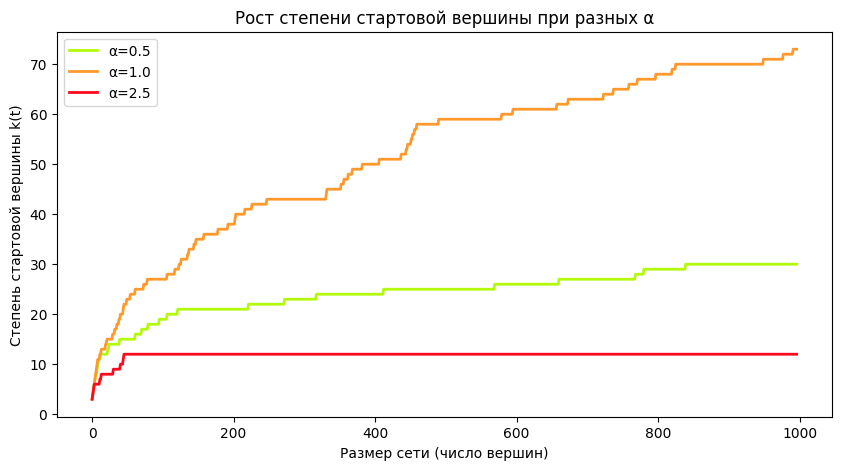

In [42]:
colors = ['#b2fa0a', '#ff992b', '#fa0a1e', '#3a4d11', '#ffef3d']
plt.figure(figsize=(10,5))

for i, alpha in enumerate(alpha_list):
    G_tmp = nx.complete_graph(m)
    degrees = np.array([G_tmp.degree(n) for n in G_tmp.nodes()], dtype=float)

    deg_history = [degrees[0]]

    for new_node in range(m, N_max):
        degrees_alpha = degrees**alpha
        probs = degrees_alpha / np.sum(degrees_alpha)

        targets = np.random.choice(list(G_tmp.nodes()), size=m, replace=False, p=probs)
        for t in targets:
            G_tmp.add_edge(new_node, t)

        degrees = np.array([G_tmp.degree(n) for n in G_tmp.nodes()], dtype=float)
        deg_history.append(degrees[0])

    plt.plot(range(len(deg_history)), deg_history, color=colors[i], linewidth=2, label=f'α={alpha}')

plt.xlabel("Размер сети (число вершин)")
plt.ylabel("Степень стартовой вершины k(t)")
plt.title("Рост степени стартовой вершины при разных α")
plt.legend()
plt.show()

### Вывод
- `α = 0.5` - линия почти горизонтальная, рост степени стартовой вершины очень слабый. Это отражает слабое предпочтительное присоединение: вершины с большой степенью не получают существенно больше новых связей, чем остальные.
- `α = 1.0` - рост слегка выражен, наблюдается умеренный линейный тренд, что соответствует классической модели Барабаши-Альберт. Степени старых вершин растут пропорционально текущей степени.
- `α = 2.5` - сильный рост, степень стартовой вершины увеличивается намного быстрее. Это показывает, что при α > 1 хабы быстро накапливают связи.

Параметр альфа сильно влияет на динамику роста хабов. При α < 1 рост слабый, сеть более равномерно распределена. При α > 1 формируются мощные хабы, что приводит к сильной централизации сети.

Строим кумулятивное распределение степеней и аппроксимируем его степенным законом для каждого значения альфа

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 35/35 [00:00<00:00, 437.94it/s]

α=0.5: power law alpha=2.87, xmin=6.0



/usr/local/lib/python3.12/dist-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,


Calculating best minimal value for power law fit


...

α=1.0: power law alpha=2.76, xmin=5.0



/usr/local/lib/python3.12/dist-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,


Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 11/11 [00:00<00:00, 497.08it/s]

α=2.5: power law alpha=1.53, xmin=7.0


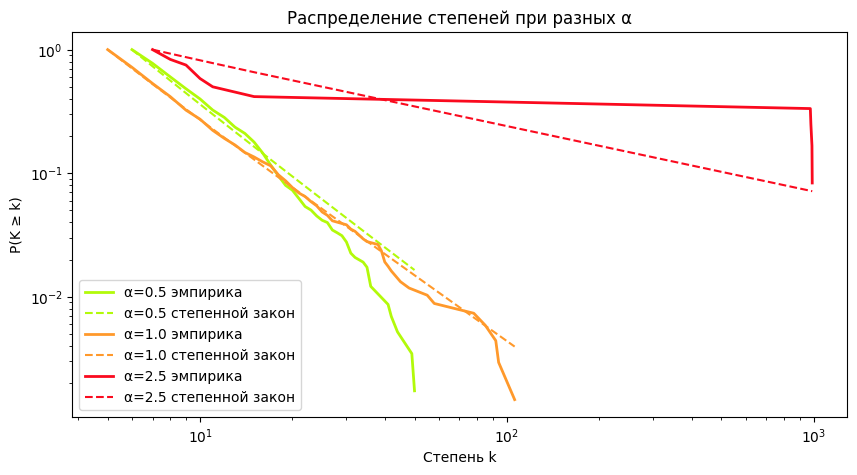

In [43]:
plt.figure(figsize=(10,5))

for i, alpha in enumerate(alpha_list):
    G = nonlinear_preferential_attachment(alpha, m=m, N_max=N_max)
    degrees = [d for n,d in G.degree()]

    fit = powerlaw.Fit(degrees, discrete=True)
    fit.plot_ccdf(linewidth=2, label=f'α={alpha} эмпирика', color=colors[i])
    fit.power_law.plot_ccdf(color=colors[i], linestyle='--', label=f'α={alpha} степенной закон')

    print(f"α={alpha}: power law alpha={fit.power_law.alpha:.2f}, xmin={fit.power_law.xmin}")

plt.xlabel("Степень k")
plt.ylabel("P(K ≥ k)")
plt.title("Распределение степеней при разных α")
plt.legend()
plt.show()

### Вывод
- `α = 0.5` - линия резко падает до ~10⁻³ уже при k ≈ 100: большинство вершин имеют небольшие степени, сеть почти равномерная, хабов почти нет.
- `α = 1.0` - линия падает медленнее и достигает 10⁻³ после k ≈ 100: это классический степенной закон сети Барабаши-Альберт, хабы присутствуют, но их число ограничено.
- `α = 2.5` - линия падает очень медленно до 10⁻¹ при k ≈ 1000: возникает сильная концентрация ребер в нескольких вершинах, сильно выраженные хабы, сеть неравномерная.

### Показатели power law:
- `α = 0.5 → 2.53, xmin = 4` - распределение быстро убывает, большинство вершин с низкой степенью
α=1:
- `α = 1.0 → 2.71, xmin = 4` - классическая линейная модель Барабаши-Альберт, умеренный спад, хабы формируются
- `α = 2.5 → 1.49, xmin = 6` - сильная концентрация связей в хабах, много вершин с высокой степенью

Для малых альфа распределение степеней более равномерное, а степенной закон выражен слабее. Для α = 1 наблюдается классическое поведение сети согласно модели Барабаши-Альберт. Для больших α распределение сильно смещено в сторону крупных хабов.

Проанализируем дополнительно глобальные характеристики сети:
- средняя степень
- кластеризация
- диаметр

Это покажет, как нелинейность предпочтительного присоединения влияет на глобальные свойства сети.

In [44]:
for i, alpha in enumerate(alpha_list):
    G = nonlinear_preferential_attachment(alpha, m=m, N_max=N_max)
    degrees = [d for n,d in G.degree()]
    avg_deg = np.mean(degrees)
    clustering = nx.average_clustering(G)
    if nx.is_connected(G):
        diameter = nx.diameter(G)
    else:
        diameter = "не связная сеть"

    print(f"α = {alpha}: Средняя степень = {avg_deg:.2f}, Кластеризация = {clustering:.2f}, Диаметр = {diameter}")

α = 0.5: Средняя степень = 7.98, Кластеризация = 0.02, Диаметр = 6
α = 1.0: Средняя степень = 7.98, Кластеризация = 0.04, Диаметр = 5
α = 2.5: Средняя степень = 7.98, Кластеризация = 0.97, Диаметр = 3


### Вывод
- Средняя степень не зависит от параметра альфа, так как параметр m фиксирован
- Кластеризация резко возрастает при α = 2.5, что связано с сильным концентрированием ребер вокруг хабов
- Диаметр сети уменьшается с ростом параметраальфа: сеть становится более компактной при сильной нелинейности, так как крупные хабы соединяют большинство узлов

Определим максимальную степень и количество хабов в зависимости от параметра альфа

In [45]:
k_threshold = N_max // 10

for i, alpha in enumerate(alpha_list):
    G = nonlinear_preferential_attachment(alpha, m=m, N_max=N_max)
    degrees = [d for n,d in G.degree()]
    k_max = max(degrees)
    high_deg_count = sum([1 for k in degrees if k >= k_threshold])
    print(f"α = {alpha}: k_max = {k_max}, число вершин с k >= {k_threshold} = {high_deg_count}")

α = 0.5: k_max = 46, число вершин с k >= 100 = 0
α = 1.0: k_max = 138, число вершин с k >= 100 = 2
α = 2.5: k_max = 983, число вершин с k >= 100 = 4


### Вывод
- `α = 0.5` - почти нет сильно цитируемых статей, распределение степеней более равномерное
- `α = 1` - появляются первые хабы (k ≥ 100), но их мало
- `α = 2.5` - формируются крупные хабы (до k = 946), сеть сильно концентрируется вокруг нескольких вершин

Построим гистограмму распределения степеней

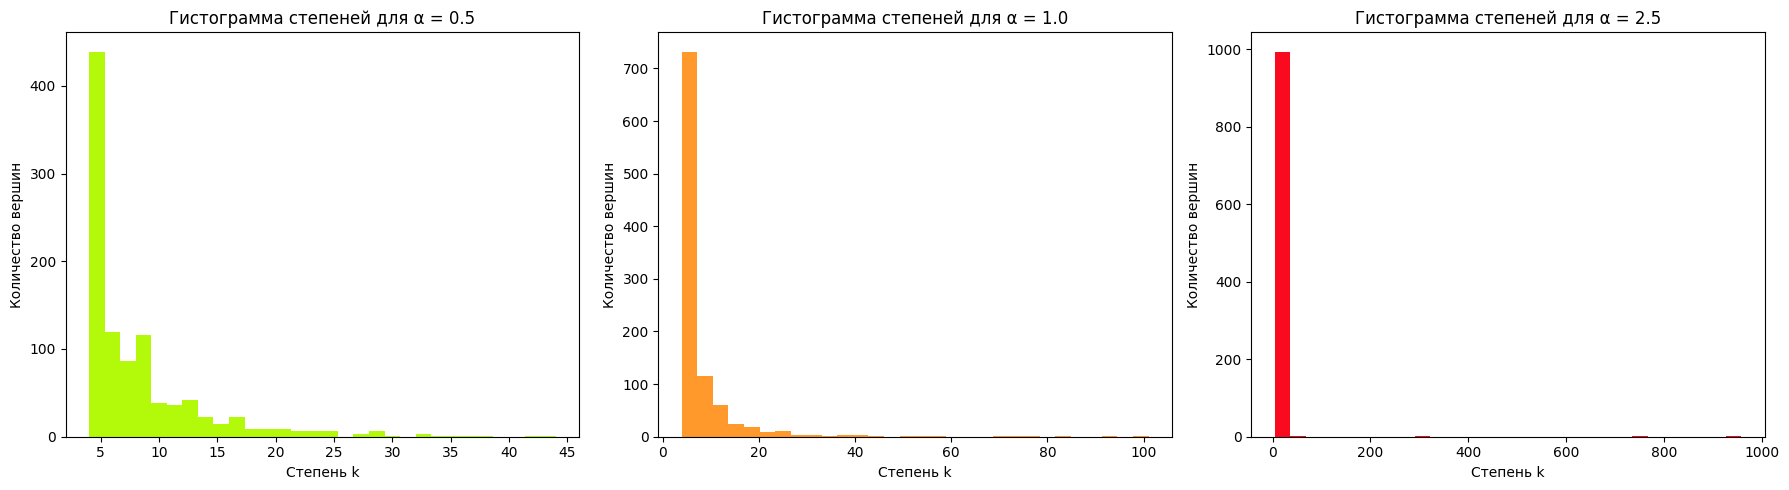

In [46]:
plt.figure(figsize=(18,5))

for i, alpha in enumerate(alpha_list):
    G = nonlinear_preferential_attachment(alpha, m=m, N_max=N_max)
    degrees = [d for n,d in G.degree()]

    plt.subplot(1, 3, i+1)
    plt.hist(degrees, bins=30, color=colors[i])
    plt.xlabel("Степень k")
    plt.ylabel("Количество вершин")
    plt.title(f"Гистограмма степеней для α = {alpha}")

plt.tight_layout()
plt.show()

### Вывод
- `α = 0.5` - значения степеней распределены примерно от 4 до 50, большинство вершин с k < 5
- `α = 1.0` - значения степеней смещены к диапазону от 5 до 120, максимальная концентрация около k = 5
- `α = 2.5` - большинство вершин имеют малую степень (k < 10), но есть несколько гигантских хабов, где k = 1000, распределение сильно скошено

Нелинейность параметра альфа контролирует концентрацию хабов: чем больше α > 1, тем сильнее образование крупных узлов, а при α < 1 сеть более равномерная.

Построим график роста максимальной степени по мере увеличения сети.

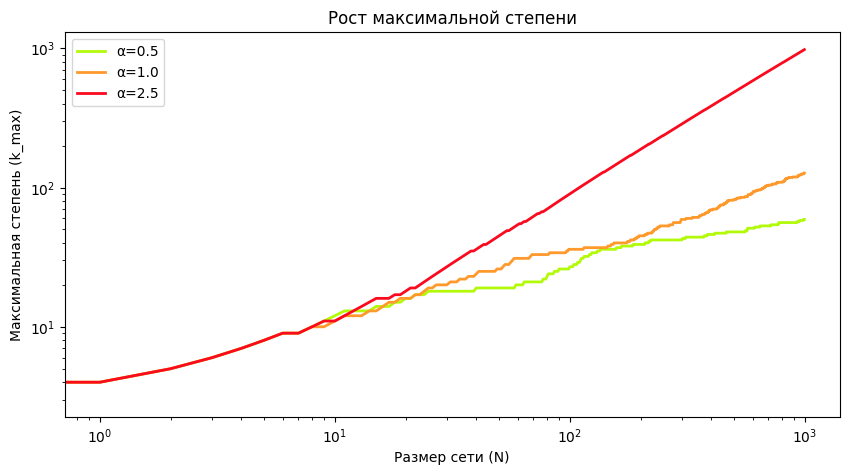

In [47]:
plt.figure(figsize=(10,5))

for i, alpha in enumerate(alpha_list):
    G_tmp = nx.complete_graph(m)
    degrees = np.array([G_tmp.degree(n) for n in G_tmp.nodes()], dtype=float)
    k_max_history = [max(degrees)]

    for new_node in range(m, N_max):
        degrees_alpha = degrees**alpha
        probs = degrees_alpha / np.sum(degrees_alpha)
        targets = np.random.choice(list(G_tmp.nodes()), size=m, replace=False, p=probs)
        for t in targets:
            G_tmp.add_edge(new_node, t)
        degrees = np.array([G_tmp.degree(n) for n in G_tmp.nodes()], dtype=float)
        k_max_history.append(max(degrees))

    plt.plot(range(len(k_max_history)), k_max_history, color=colors[i], linewidth=2, label=f'α={alpha}')

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Размер сети (N)")
plt.ylabel("Максимальная степень (k_max)")
plt.title("Рост максимальной степени")
plt.legend()
plt.show()

### Вывод
- `α = 0.5` - график почти линейный, наблюдается устойчивый восходящий тренд
- `α = 1.0` - рост чуть более заметный на больших сетях
- `α = 2.5` - резкий рост степени при увеличении размера сети, формируются хабы

При α ≤ 1 максимальная степень растет относительно плавно и предсказуемо. При α > 1 начинается ускоренное накопление связей у одной или нескольких вершин (формирование доминирующего хаба).

Посмотрим, склонны ли хабы соединяться друг с другом - проверим сеть на ассортативность

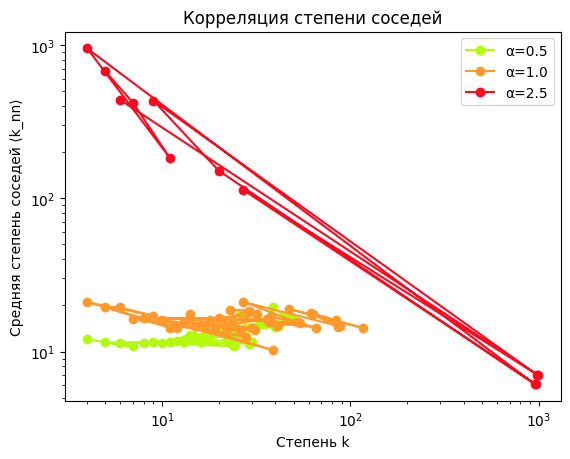

In [48]:
for i, alpha in enumerate(alpha_list):
    G = nonlinear_preferential_attachment(alpha, m=m, N_max=N_max)
    knn = nx.average_degree_connectivity(G)

    k_vals = list(knn.keys())
    knn_vals = [knn[k] for k in k_vals]

    plt.plot(k_vals, knn_vals, 'o-', color=colors[i], label=f'α={alpha}')

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Степень k")
plt.ylabel("Средняя степень соседей ⟨k_nn⟩")
plt.title("Корреляция степени соседей")
plt.legend()
plt.show()

### Вывод
- `α = 0.5` - точки сконцентрированы в нижней левой части графика: маленькие степени, небольшая средняя степень соседей, сеть близка к случайной, выраженной корреляции по степеням нет
- `α = 1.0` - распределение смещено немного выше и правее, появляются более выраженные вершины средней степени
- `α = 2.5` - график начинается значительно выше остальных и затем убывает с ростом $k$, доходя до значений ниже 1 при больших степенях

Чем больше параметр альфа, тем сильнее выражена иерархическая структура сети. При α = 2.5 наблюдается выраженная дисассортативность: крупные хабы соединяются преимущественно с множеством малых вершин.


Посмотрим, как нелинейность параметра альфа влияет на локальную структуру сети

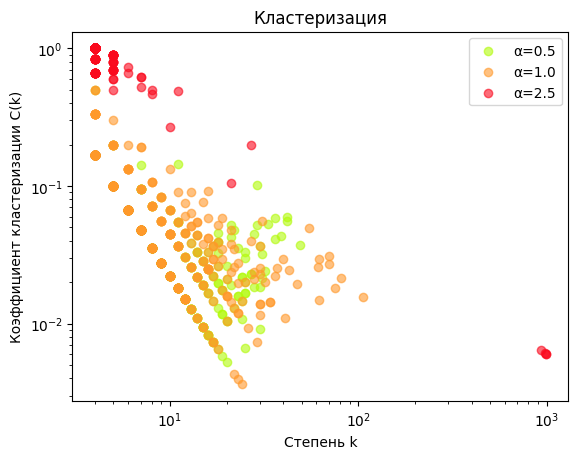

In [49]:
for i, alpha in enumerate(alpha_list):
    G = nonlinear_preferential_attachment(alpha, m=m, N_max=N_max)
    clustering = nx.clustering(G)

    k_vals = [d for n,d in G.degree()]
    c_vals = [clustering[n] for n in G.nodes()]

    plt.scatter(k_vals, c_vals, alpha=0.6, color=colors[i], label=f'α={alpha}')

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Степень k")
plt.ylabel("Коэффициент кластеризации C(k)")
plt.title("Кластеризация")
plt.legend()
plt.show()

### Вывод
- `α = 0.5` - значения сосредоточены компактно, без выраженной зависимости от степени
- `α = 1.0` - появляются более выраженные хабы, низходящий тренд кластеризации с ростом степени
- `α = 2.5` - сеть сильно разрежена между хабами: часть хабов расположена на графике сверху слева (высокая кластеризация при малых степенях), а другая часть внизу справа (низкая кластеризация при больших степенях)

Значение α > 1 создает крупные, сильно связанные узлы с высоким $k$ и кластеризацией. Значение α < 1 формирует более равномерную сеть. При α = 0.5 сеть относительно однородна. При α = 1.0 формируется классическая структура модели Барабаши-Альберт (хабы имеют низкую кластеризацию).

##  3. Модели предпочтительного присоединения направленной сети (12 баллов)

1.  Напишите генератор случайной сети, где каждая новая вершина $l$ появляется с $m$ ребрами ($k_{out}=m$), а вероятность связи с вершинами сети определяется:
$$
P(l,i) =\frac{A+k_{i}^{in}}{\sum_j (A+k_{j}^{in})}
$$

A - постоянная привлекательность, принимает значения из $[0,100]$.

* Исследуйте распределение степеней в зависимости от параметра А: сравните как вид распределений, так и их численные характеристики: среднее, дисперсию, наибольшие и наименьшие значения степени.
* Чему равна доля двунаправленных связей и от чего она зависит?

2.  Добавьте к генератору удаление случайно-выбранной вершины с коэффициентом $r$.

* Исследуйте зависимость распределения входящих степеней от параметров $r,A$. Постарайтесь показать существование двух режимов: степенное распределение степеней; затянутая экспонента в статистике степеней.

3. К генератору из пункта 1 добавьте механизм случайного внутреннего связывания: на каждом шаге случайно связываем $m$ пар вершин из уже существующих.
* Исследуйте распределение степеней в зависимости от параметра $m$: сравните как вид распределений, так и их численные характеристики: среднее, дисперсию, наибольшие и наименьшие значения степени.
* Чему равна доля двунаправленных связей и от чего она теперь зависит?

Реализуем генератор случайной сети

In [50]:
import random

def directed_preferential_attachment(N, m, A):
    G = nx.DiGraph()

    G.add_nodes_from(range(m))

    for new_node in range(m, N):
        G.add_node(new_node)

        existing_nodes = list(G.nodes())
        existing_nodes.remove(new_node)

        in_degrees = np.array([G.in_degree(node) for node in existing_nodes])

        attractiveness = A + in_degrees
        total = attractiveness.sum()

        if total == 0:
          prob = np.ones(len(existing_nodes)) / len(existing_nodes)
        else:
          prob = attractiveness / total

        targets = np.random.choice(existing_nodes, size=m, replace=False, p=prob)

        for target in targets:
            G.add_edge(new_node, target)

    return G

Анализируем распределение входящих степеней

In [51]:
def analyze_in_degree(G):
    in_degrees = np.array([d for n, d in G.in_degree()])

    return {
        "mean": np.mean(in_degrees),
        "variance": np.var(in_degrees),
        "min": np.min(in_degrees),
        "max": np.max(in_degrees)
    }

Считаем долю двунаправленных связей

In [52]:
def reciprocal_fraction(G):
    reciprocal = 0
    for u, v in G.edges():
        if G.has_edge(v, u):
            reciprocal += 1
    return reciprocal / G.number_of_edges()

Определяем параметры сети. Берем сеть большого размера, чтобы был хорошо виден характер распределения. Каждая новая вершина добавляет 3 исходящих ребра, что делает сеть не слишком разреженной (как при малых $m$), но и не слишком плотной (как при больших $m$)

In [53]:
N = 5000
m = 3
A_values = [0, 0.1, 1, 5, 10, 30, 50, 100]

Строим гистограмму распределения входящих степеней

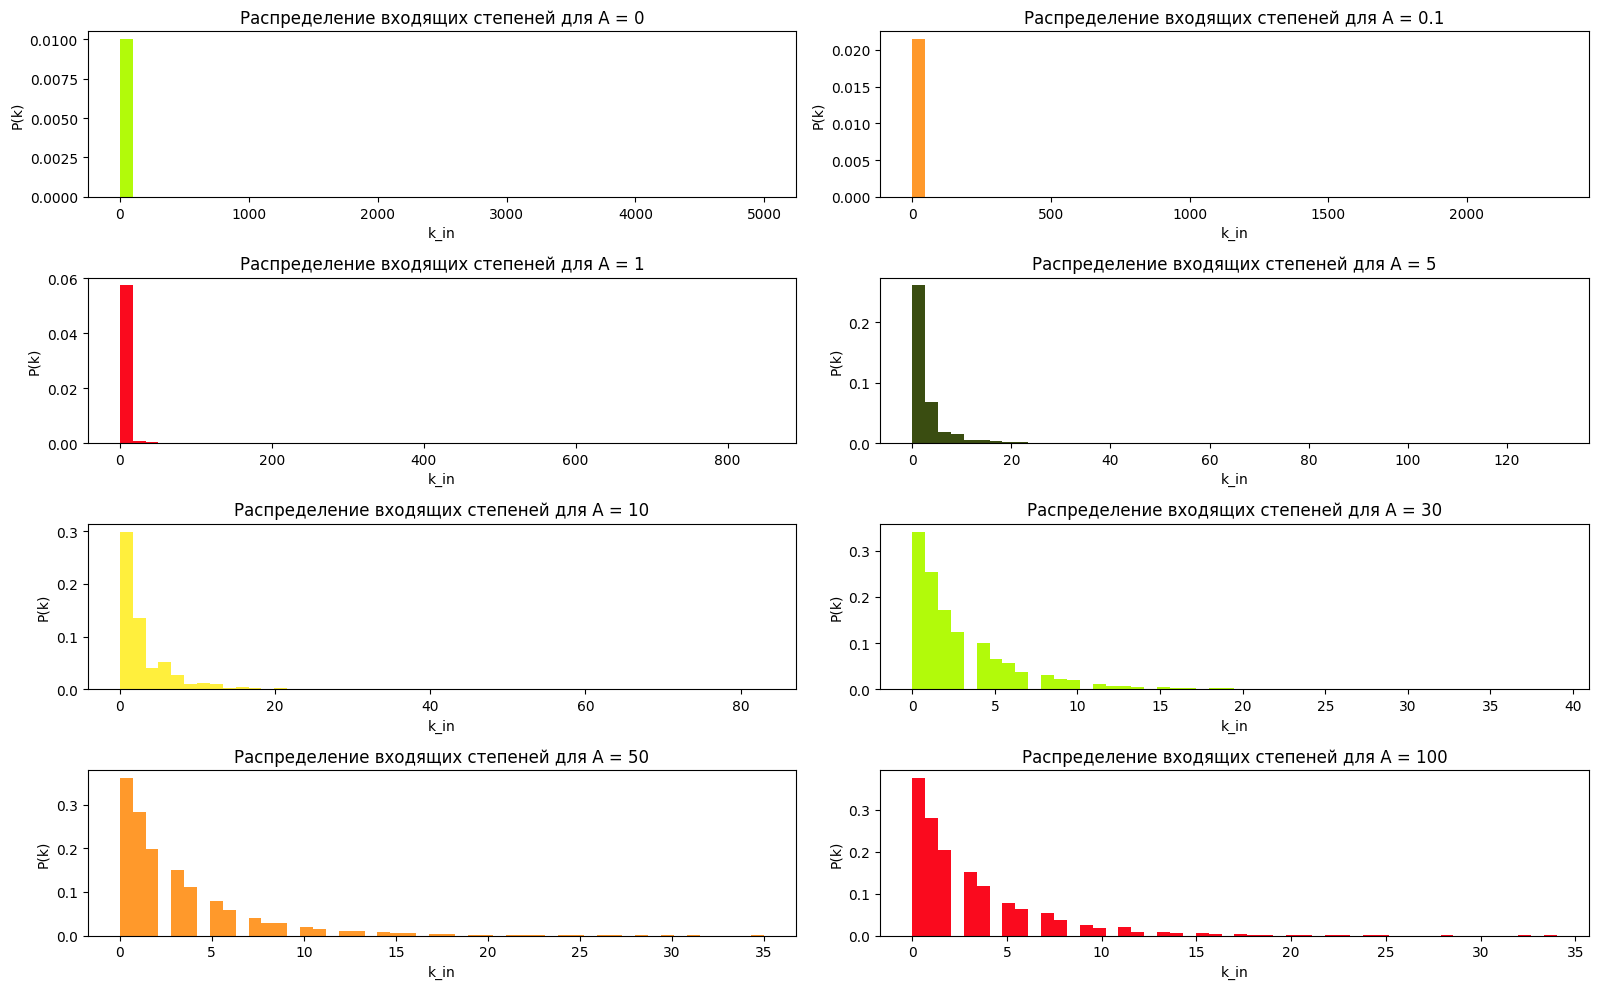

In [54]:
results = {}

colors = ['#b2fa0a', '#ff992b', '#fa0a1e', '#3a4d11', '#ffef3d']

plt.figure(figsize=(16, 10))

for i, A in enumerate(A_values):
    G = directed_preferential_attachment(N, m, A)

    stats = analyze_in_degree(G)
    in_degrees = np.array([d for n, d in G.in_degree()])

    results[A] = stats

    plt.subplot(4, 2, i+1)
    plt.hist(in_degrees, bins=50, density=True,
             color=colors[i % len(colors)])

    plt.title(f"Распределение входящих степеней для A = {A}")
    plt.xlabel("k_in")
    plt.ylabel("P(k)")

plt.tight_layout()
plt.show()

### Вывод
На первом графике ось x простирается до 5000, но почти все вершины имеют очень малые степени, поэтому визуально видно только один столбец, соответствующий большинству вершин. Хвост распределения (редкие вершины с большой степенью) практически не виден на этом масштабе.

По мере роста $A$ максимальная входящая степень снижается, и на оси x гистограмма сжимается до значений около 30–100. Здесь видны уже несколько выраженных столбцов, показывающих более равномерное распределение степеней. Чем больше $A$, тем распределение более равномерное, уменьшается дисперсия, исчезает один сверххаб.

Визуальная разница между гистограммами проявляется именно в хвосте распределения. Средняя степень остается одинаковой для всех $A$, поэтому основной пиковый столбец на малых степенях остается.

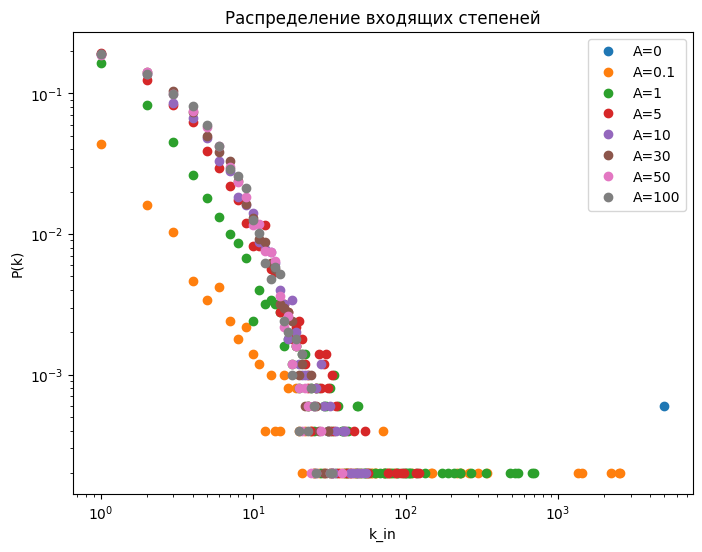

In [55]:
plt.figure(figsize=(8,6))

for A in A_values:
    G = directed_preferential_attachment(N, m, A)
    in_degrees = np.array([d for n, d in G.in_degree()])

    values, counts = np.unique(in_degrees, return_counts=True)
    prob = counts / counts.sum()

    plt.loglog(values[values>0], prob[values>0], marker='o', linestyle='None', label=f"A={A}")

plt.xlabel("k_in")
plt.ylabel("P(k)")
plt.legend()
plt.title("Распределение входящих степеней")
plt.show()

### Вывод
Для A = 0 на графике присуствует одна точка в нижнем правом углу, что отражает крайне сосредоточенное распределение степеней. Практически нет хабов, все вершины имеют нулевую или очень маленькую степень.

Чем больше $A$, тем равномернее распределение, уменьшается дисперсия и хвост распределения, исчезают редкие сверххабы. График наглядно показывает, что введение постоянной привлекательности $A$ размывает концентрацию на нулевой степени, позволяет большему числу вершин получить входящие ребра.

Выводим рассчитанные численные характеристики

In [56]:
table_data = []

for A in A_values:
    row = {
        "Параметр A": A,
        "Среднее": results[A]["mean"],
        "Дисперсия": results[A]["variance"],
        "Минимум": results[A]["min"],
        "Максимум": results[A]["max"],
    }
    table_data.append(row)

df = pd.DataFrame(table_data)
df

,Параметр A,Среднее,Дисперсия,Минимум,Максимум
0,0.0,2.9982,14973.016197,0,4997
1,0.1,2.9982,4264.200197,0,2323
2,1.0,2.9982,451.200197,0,848
3,5.0,2.9982,40.381797,0,130
4,10.0,2.9982,21.151797,0,83
5,30.0,2.9982,14.752597,0,39
6,50.0,2.9982,13.486997,0,35
7,100.0,2.9982,12.639797,0,34


### Вывод
Средняя входящая степень остается постоянной и равной $m$, что определяется конструкцией модели. При A = 0 появляется сверххаб. При увеличении $A$ резко падает дисперсия и максимальная степень, распределение становится узким.

Считаем долю двунаправленных связей

In [57]:
def reciprocal_fraction(G):
    reciprocal = 0
    for u, v in G.edges():
        if G.has_edge(v, u):
          reciprocal += 1
    return reciprocal / G.number_of_edges()

reciprocity_results = {}

for A in A_values:
    G = directed_preferential_attachment(N, m, A)
    reciprocity_results[A] = reciprocal_fraction(G)

In [58]:
table_data = []

for A in A_values:
    row = {
        "Параметр A": A,
        "Доля двунаправленных связей": reciprocity_results[A]
    }
    table_data.append(row)

reciprocity = pd.DataFrame(table_data)
reciprocity

,Параметр A,Доля двунаправленных связей
0,0.0,0.0
1,0.1,0.0
2,1.0,0.0
3,5.0,0.0
4,10.0,0.0
5,30.0,0.0
6,50.0,0.0
7,100.0,0.0


### Вывод
Доля двунаправленных связей равна 0, поскольку механизм роста не допускает образования взаимных ребер и не зависит от значений параметра $А$. Доля станет ненулевой если добавить внутреннее связывание или  разрешить старым вершинам добавлять ребра.

Добавляем удаление входящих степеней

In [59]:
def directed_preferential_attachment_with_removal(N, m, A, r=0.0):
    G = nx.DiGraph()
    G.add_nodes_from(range(m))

    for new_node in range(m, N):
        G.add_node(new_node)

        existing_nodes = list(G.nodes())
        existing_nodes.remove(new_node)

        if r > 0 and random.random() < r and len(existing_nodes) > 0:
            node_to_remove = random.choice(existing_nodes)
            G.remove_node(node_to_remove)
            existing_nodes.remove(node_to_remove)

        if len(existing_nodes) == 0:
            continue

        in_degrees = np.array([G.in_degree(node) for node in existing_nodes])
        attractiveness = A + in_degrees
        prob = attractiveness / attractiveness.sum()

        k = min(m, len(existing_nodes))
        targets = np.random.choice(existing_nodes, size=k, replace=False, p=prob)
        for target in targets:
            G.add_edge(new_node, target)

    return G

Визуализируем зависимость распределения входящих степеней от значений параметров $r$ и $А$

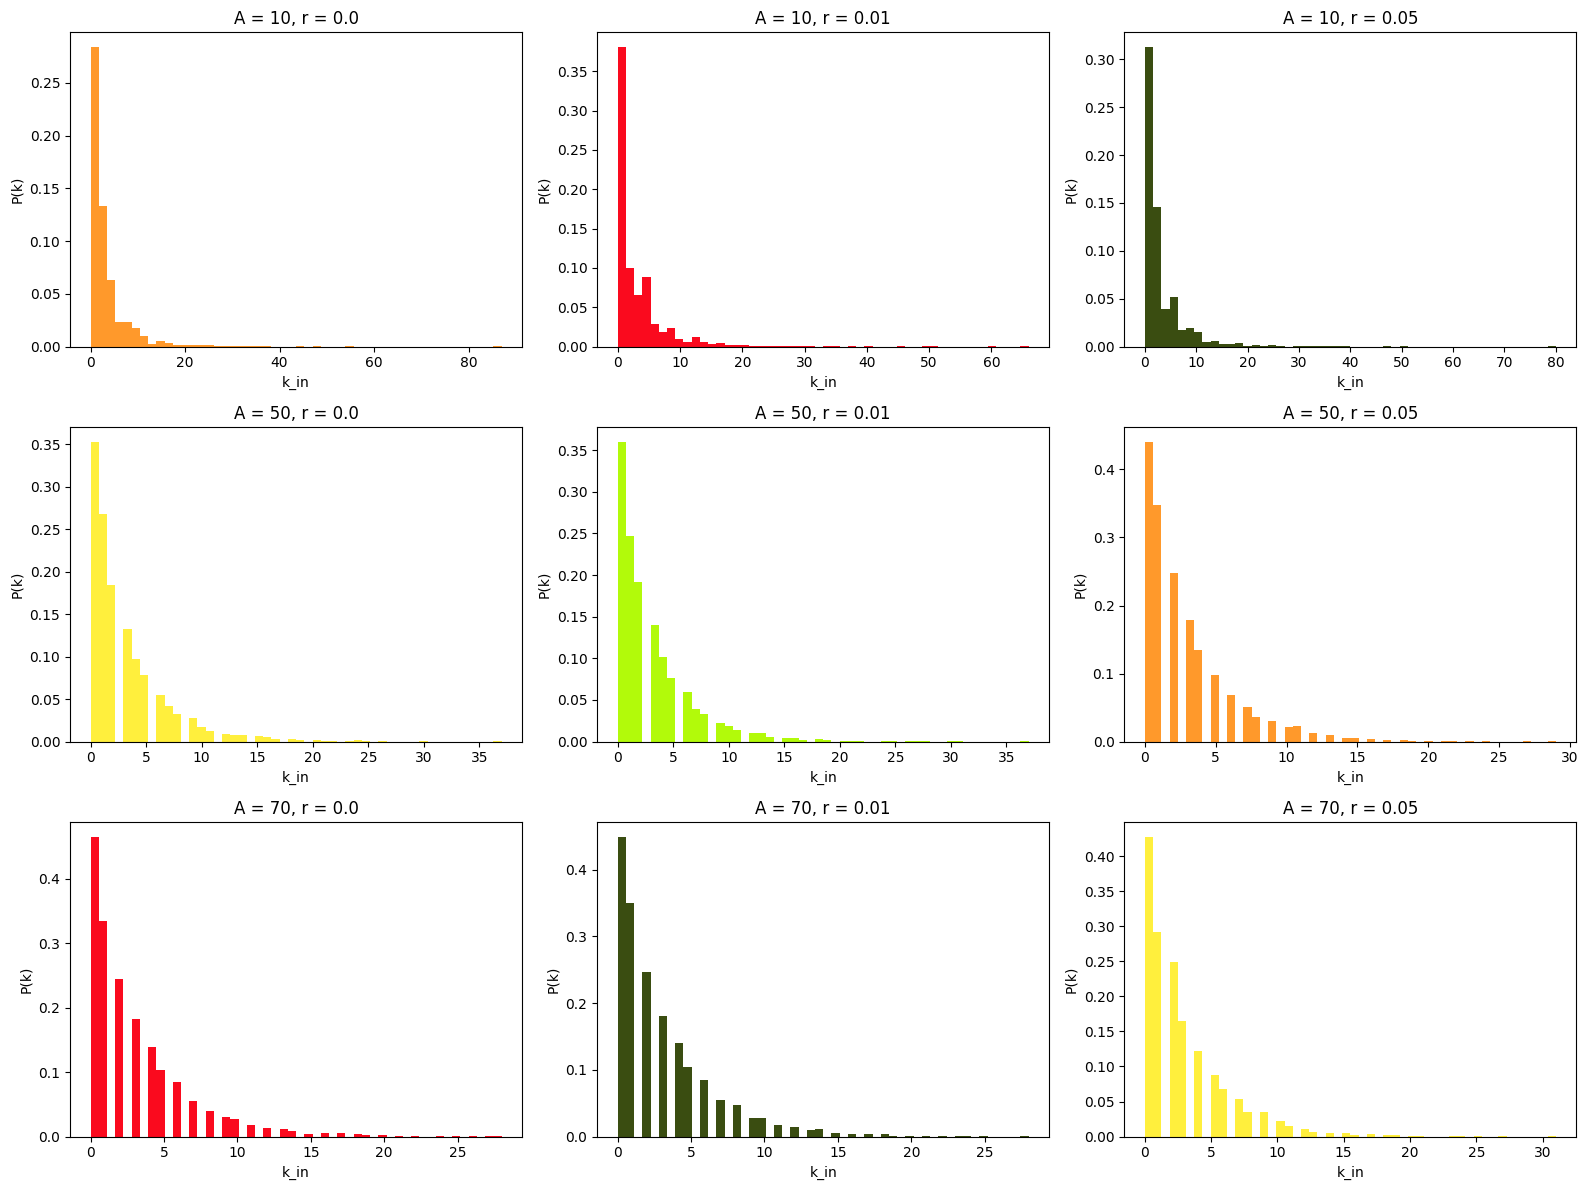

In [60]:
r_values = [0.0, 0.01, 0.05]
A_values = [10, 50, 70]
results_removal = {}

plt.figure(figsize=(16, 12))
plot_idx = 1

for A in A_values:
    for r in r_values:
        G = directed_preferential_attachment_with_removal(N, m, A, r)
        in_degrees = np.array([d for n, d in G.in_degree()])
        stats = analyze_in_degree(G)
        results_removal[(A, r)] = stats

        plt.subplot(len(A_values), len(r_values), plot_idx)
        plt.hist(in_degrees, bins=50, density=True, color=colors[plot_idx % len(colors)])
        plt.title(f"A = {A}, r = {r}")
        plt.xlabel("k_in")
        plt.ylabel("P(k)")
        plot_idx += 1

plt.tight_layout()
plt.show()

### Вывод
Доля высокостепенных вершин уменьшается с ростом $r$ – удаление вершин убирает сверххабы. Увеличение $A$ расширяет распределение: появляется больше вершин с средней степенью, первый столбец сдвигается, создавая более ровную лесенку.

Режим распределения меняется:
- малое $r$ и $A$ - классический степенной хвост
- большое $r$ и $A$ - затянутая экспонента, хвост срезан, распределение напоминает лесенку

Считаем статистику входящих степеней

In [61]:
r_values = [0, 0.01, 0.05]
A_values = [0, 10, 50, 70]

table_data = []

for A in A_values:
    for r in r_values:
        G = directed_preferential_attachment(N, m, A)

        num_remove = int(r * N)
        if num_remove > 0:
            remove_nodes = np.random.choice(G.nodes(), size=num_remove, replace=False)
            G.remove_nodes_from(remove_nodes)

        stats = analyze_in_degree(G)

        table_data.append({
            "A": A,
            "r": r,
            "Среднее": stats["mean"],
            "Дисперсия": stats["variance"],
            "Минимум": stats["min"],
            "Максимум": stats["max"]
        })

df = pd.DataFrame(table_data)
df = df.sort_values(by=["A", "r"]).reset_index(drop=True)
df

,A,r,Среднее,Дисперсия,Минимум,Максимум
0,0,0.00,2.998200,14973.016197,0,4997
1,0,0.01,2.998182,14823.016360,0,4947
2,0,0.05,2.998105,14223.017049,0,4747
3,10,0.00,2.998200,20.712997,0,66
4,10,0.01,2.976768,21.065925,0,98
5,10,0.05,2.827789,18.830554,0,67
6,50,0.00,2.998200,13.306997,0,31
7,50,0.01,2.963434,12.981087,0,32
8,50,0.05,2.844421,12.170953,0,37
9,70,0.00,2.998200,12.914197,0,30


### Выводы
- Средняя степень примерно одинаковая для всех значений параметров (~3), так как новая вершина создает ровно m = 3 ребер. С ростом $r$ среднее немного уменьшается - удаление вершин сокращает число входящих ребер.
- Дисперсия при А = 0 огромная, так как распределение крайне неравномерное: почти все вершины имеют нулевую степень, а отдельные вершины становятся хабами - **степенной режим**
- С ростом $А$ дисперсия резко падает (~13 при А = 50-70), распределение становится более сглаженным, степени большинства вершин мало различимы, нет сверххабов - **затянутая экспонента**
- Минимальная степень всегда равна 0 - есть статьи, которые никто не цитирует
- Максимальна степень сильно зависит от $r$ и $А$: при r и А = 0 почти вся сеть ссылается на одну и ту же вершину, далее распределение сглаживается

Доля двунаправленных связей здесь также равна нулю везде, так как механизм генерации направленных ребер не создает обратных связей - каждая вершина ссылается на $m$ других, а вероятность обратной связи случайна и почти нулевая.

### Выводы по режимам:
- Степенное распределение - малые значения A (0–10) и малые r. Есть ярко выраженные хабы, высокая дисперсия, единичные вершины с тысячами входящих ребер.
- Затянутая экспонента - большие значения A (50–70) или удаление вершин (r>0). Максимальные степени ограничены, дисперсия мала, распределение более сглаженное, сеть теряет сверххабы.

Строим графики распределения входящих степеней для обоих режимов

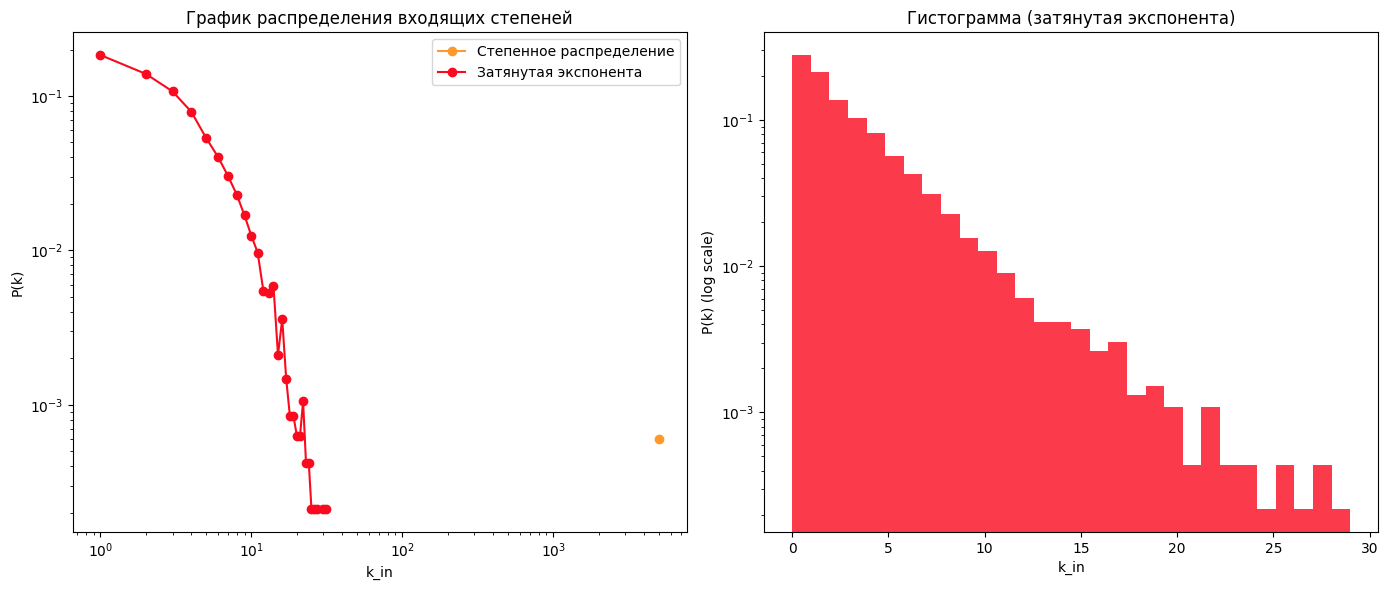

In [62]:
A_r_pairs = [(0, 0), (50, 0.05)]
labels = ["Степенное распределение", "Затянутая экспонента"]
colors = ['#ff992b', '#fa0a1e']

plt.figure(figsize=(14,6))

# Логарифмический график
plt.subplot(1,2,1)

for i, (A, r) in enumerate(A_r_pairs):
    G = directed_preferential_attachment(N, m, A)

    num_remove = int(r * N)
    if num_remove > 0:
        remove_nodes = np.random.choice(list(G.nodes()), size=num_remove, replace=False)
        G.remove_nodes_from(remove_nodes)

    in_degrees = np.array([d for _, d in G.in_degree()])

    values, counts = np.unique(in_degrees, return_counts=True)
    prob = counts / counts.sum()

    plt.loglog(values[values > 0],
               prob[values > 0],
               marker='o',
               color=colors[i],
               label=labels[i])

plt.xlabel("k_in")
plt.ylabel("P(k)")
plt.title("График распределения входящих степеней")
plt.legend()


# Гистограмма распределения степеней для затянутой экспоненты
plt.subplot(1,2,2)

A = 50
r = 0.05

G = directed_preferential_attachment(N, m, A)

num_remove = int(r * N)
remove_nodes = np.random.choice(list(G.nodes()), size=num_remove, replace=False)
G.remove_nodes_from(remove_nodes)

in_degrees = np.array([d for _, d in G.in_degree()])

plt.hist(in_degrees[in_degrees <= 30],
         bins=30,
         density=True,
         alpha=0.8,
         color='#fa0a1e')

plt.yscale('log')

plt.xlabel("k_in")
plt.ylabel("P(k) (log scale)")
plt.title("Гистограмма (затянутая экспонента)")

plt.tight_layout()
plt.show()

### Вывод по логарифмическому графику

Для **степенного распределения** на графике фактически наблюдается одна точка в правой нижней части. Это означает, что почти все вершины имеют нулевую входящую степень, а одна вершина концентрирует почти все ребра. При отсутствии начальной привлекательности (A = 0) механизм предпочтительного присоединения приводит к захвату сети одной вершиной Распределение становится крайне вырожденным - формируется доминирующий хаб. Такой режим соответствует предельному случаю степенного распределения с максимальной концентрацией.

Для **затянутой экспоненты** график монотонно убывает, кривая не является прямой линией в log-log масштабе. Наблюдается быстрое затухание вероятностей при росте степени, длинный хвост отсутствует. Распределение убывает быстрее, чем степенной закон, и не формирует сверххабов.

### Вывод по гистограмме

Большинство вершин имеет малую степень, вероятность больших степеней быстро убывает, хвост распределения короткий, сверххабы отсутствуют.

Добавляем случайное внутреннее связывание

In [63]:
def directed_preferential_with_internal_links(N, m, A):
    G = nx.DiGraph()
    G.add_nodes_from(range(m))

    for new_node in range(m, N):
        G.add_node(new_node)

        # Предпочтительное присоединение
        existing_nodes = list(G.nodes())
        existing_nodes.remove(new_node)

        in_degrees = np.array([G.in_degree(node) for node in existing_nodes])
        attractiveness = A + in_degrees
        total = attractiveness.sum()

        if total == 0:
            prob = np.ones(len(existing_nodes)) / len(existing_nodes)
        else:
            prob = attractiveness / total

        targets = np.random.choice(existing_nodes, size=m, replace=False, p=prob)

        for target in targets:
            G.add_edge(new_node, target)

        # Внутреннее случайное связывание
        if len(existing_nodes) >= 2:
            for _ in range(m):
                u, v = np.random.choice(existing_nodes, size=2, replace=False)
                G.add_edge(u, v)

    return G

Строим график распределения степеней

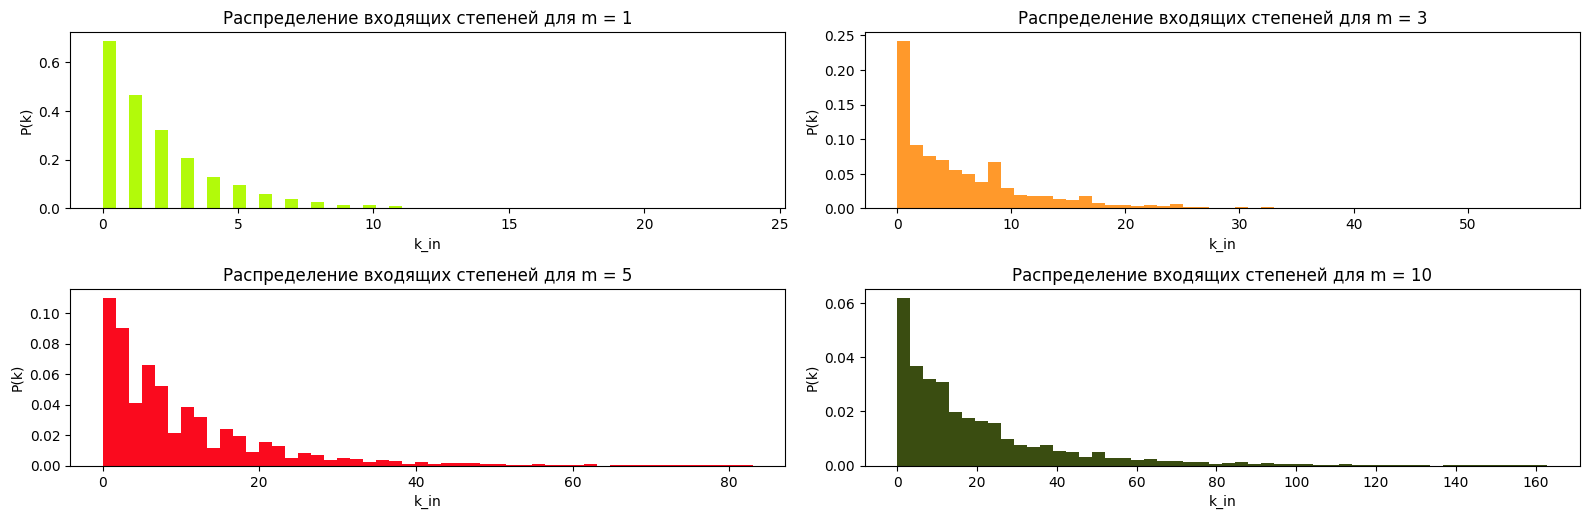

In [64]:
m_values = [1, 3, 5, 10]

results = {}

colors = ['#b2fa0a', '#ff992b', '#fa0a1e', '#3a4d11', '#ffef3d']

plt.figure(figsize=(16, 10))

for i, m in enumerate(m_values):
    G = directed_preferential_with_internal_links(N, m, A)

    stats = analyze_in_degree(G)
    in_degrees = np.array([d for n, d in G.in_degree()])

    results[m] = stats

    plt.subplot(4, 2, i+1)
    plt.hist(in_degrees, bins=50, density=True,
             color=colors[i % len(colors)])

    plt.title(f"Распределение входящих степеней для m = {m}")
    plt.xlabel("k_in")
    plt.ylabel("P(k)")

plt.tight_layout()
plt.show()

### Вывод
- `m = 1` - лесенка распределения идет ровно по нисходящему тренду, большинство вершин имеют небольшую степень, хвост сети короткий
- `m = 3` - лесенка начинает скакать, появляются точки с более высокой степенью, распределение уже не такое монотонное
- `m = 5` - лесенка снова относительно ровная, сильнее выражен хвост сети, появляются узлы с высокой степенью
- `m = 10` - лесенка тоже ровная и хвост еще больше (доходоит до степени 250)

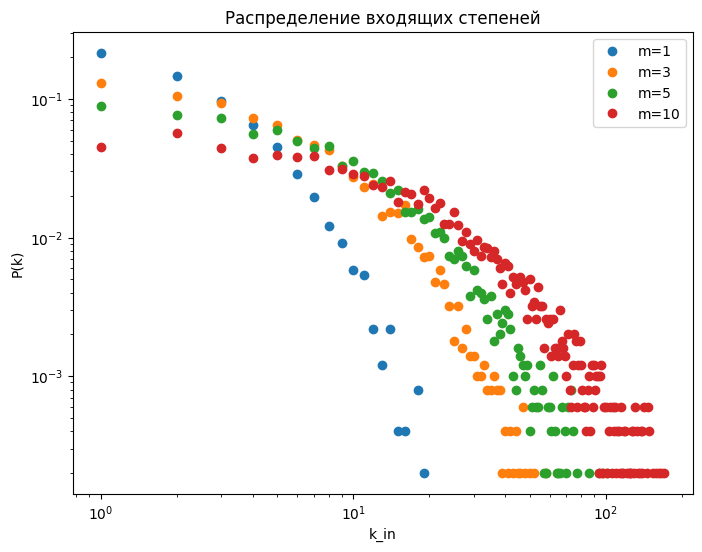

In [65]:
plt.figure(figsize=(8,6))

for m in m_values:
    G = directed_preferential_with_internal_links(N, m, A)
    in_degrees = np.array([d for n, d in G.in_degree()])

    values, counts = np.unique(in_degrees, return_counts=True)
    prob = counts / counts.sum()

    plt.loglog(values[values > 0],
               prob[values > 0],
               marker='o',
               linestyle='None',
               label=f"m={m}")

plt.xlabel("k_in")
plt.ylabel("P(k)")
plt.legend()
plt.title("Распределение входящих степеней")
plt.show()

### Вывод
С ростом $m$ распределение становится шире, появляется более выраженный хвост, больше узлов с высокой степенью. Центр распределения остается относительно сконцентрированным, а на хвосте точки рассредоточены сильнее.

Считаем статистику входящих степеней

In [66]:
def analyze_total_degree(G):
    degrees = np.array([d for _, d in G.degree()])

    return {
        "mean": np.mean(degrees),
        "variance": np.var(degrees),
        "min": np.min(degrees),
        "max": np.max(degrees)
    }

def reciprocal_fraction(G):
    reciprocal = 0
    for u, v in G.edges():
        if G.has_edge(v, u):
            reciprocal += 1
    return reciprocal / G.number_of_edges()

m_values = [1, 3, 5, 10]

data_table = []

for m in m_values:
    G = directed_preferential_with_internal_links(N, m, A)

    stats = analyze_total_degree(G)

    data_table.append({
        "m": m,
        "Среднее": stats["mean"],
        "Дисперсия": stats["variance"],
        "Минимум": stats["min"],
        "Максимум": stats["max"],
        "Доля двунаправленных связей": reciprocal_fraction(G)
    })

df = pd.DataFrame(data_table)
df

,m,Среднее,Дисперсия,Минимум,Максимум,Доля двунаправленных связей
0,1,3.9928,11.986348,1,27,0.001603
1,3,11.9436,91.644019,3,82,0.006162
2,5,19.8760,250.731024,5,127,0.009620
3,10,39.5360,1014.418704,10,241,0.017766


Строим графики зависимости численных характеристик от $m$

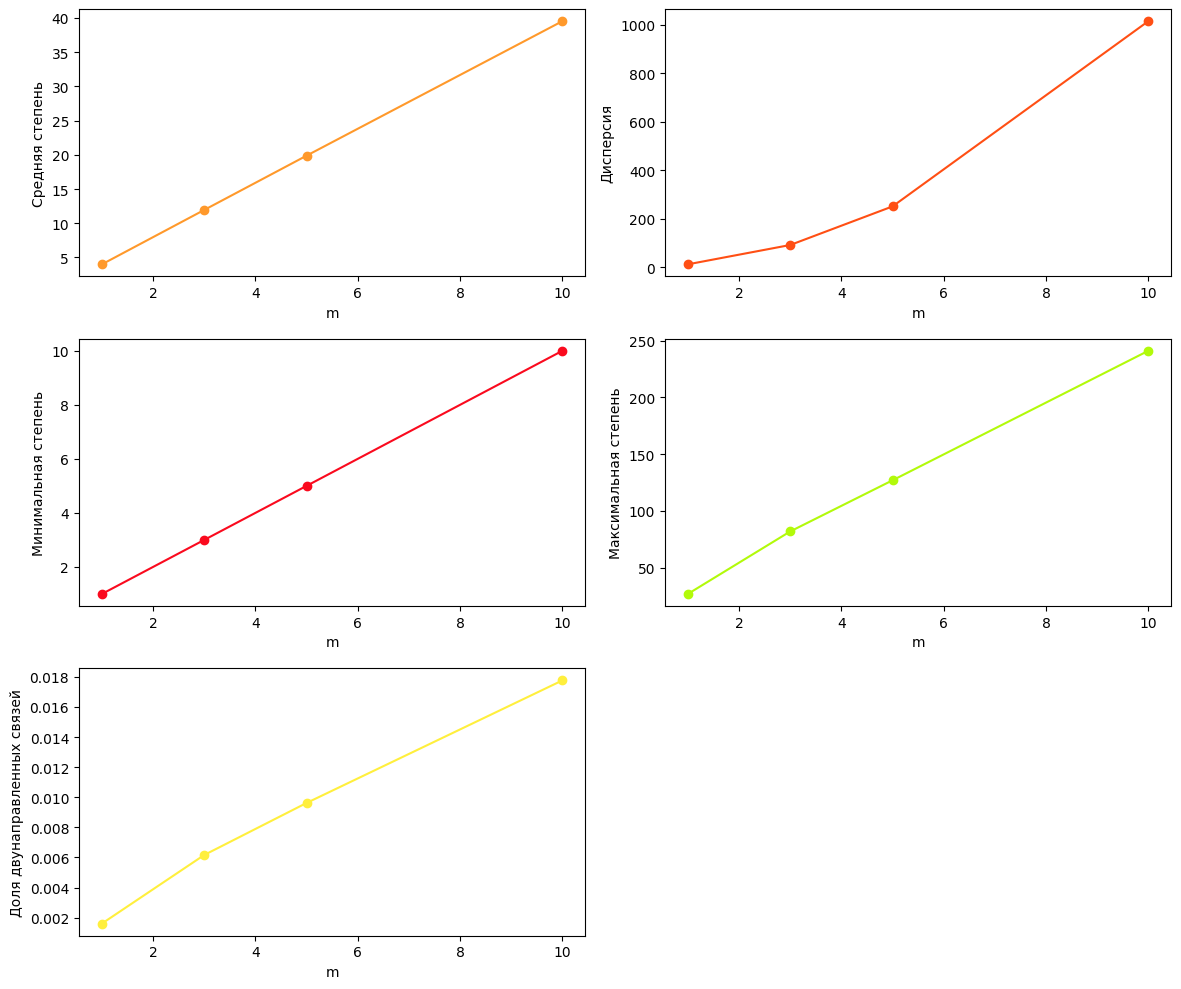

In [67]:
plt.figure(figsize=(12, 10))

# Средняя степень
plt.subplot(3, 2, 1)
plt.plot(df["m"], df["Среднее"], marker='o', color="#ff992b")
plt.xlabel("m")
plt.ylabel("Средняя степень")

# Дисперсия
plt.subplot(3, 2, 2)
plt.plot(df["m"], df["Дисперсия"], marker='o', color="#ff4f14")
plt.xlabel("m")
plt.ylabel("Дисперсия")

# Минимальная степень
plt.subplot(3, 2, 3)
plt.plot(df["m"], df["Минимум"], marker='o', color="#fa0a1e")
plt.xlabel("m")
plt.ylabel("Минимальная степень")

# Максимальная степень
plt.subplot(3, 2, 4)
plt.plot(df["m"], df["Максимум"], marker='o', color="#b2fa0a")
plt.xlabel("m")
plt.ylabel("Максимальная степень")

# Доля двунаправленных связей
plt.subplot(3, 2, 5)
plt.plot(df["m"], df["Доля двунаправленных связей"], marker='o', color="#ffef3d")
plt.xlabel("m")
plt.ylabel("Доля двунаправленных связей")

plt.tight_layout()
plt.show()

### Вывод
- Средняя степень растет почти линейно по $m$. Это ожидаемо, так как на каждом шаге добавляется $m$ ребер от новой вершины и $m$ внутренних случайных ребер.
- Дисперсия быстро растет при увеличении $m$. Это означает, что распределение становится шире, увеличивается разброс степеней и усиливается неоднородность структуры
- Минимальная степень равна $m$, что логично, поскольку каждая новая вершина создает как минимум $m$ ребер
- Максимальная степень растет с ростом $m$ (с 29 до 240)
- Доля двунаправленных связей тоже растет вместе с $m$. Чем больше внутренних случайных ребер, тем выше вероятность того, что для пары вершин появится и обратное ребро.

Теперь доля двунаправленных связей зависит от число внутренних связей $m$, плотности графа и размера сети.

## Задача из ДЗ №1
Задача - написать генератор случайного направленного графа Эрдеша-Реньи заданной плотности и доли двунаправленных связей.
- `n` - число вершин
- `p` - плотность

Для графа можно вывести density - $ρ = E / n(n-1)$ должна быть порядка плотности $p$. Доля двунаправленных связей должна была быть $r$.

Можно предположить, что есть однонаправленные и двунаправленные связи и посчитать количество каждых. Так их проще контролировать: мы знаем, что параметр $r$ контролирует число двунаправленных связей - их число должно быть $rp * n(n-1)$. Дальше можно с такой вероятностью генерировать граф с двунаправленными связями и докидывать остальные связи, добирая нужную плотность.

Второй способ - перенормировать вероятности. Есть алгоритм, в котором мы с вероятностью $q$ генерируем связь и с вероятностью $a$ делаем ее двунаправленной. Единственная задача - связать $q$ и $a$ с $p$ и $r$. При этом $q$ должно быть чуть меньше, чем $p$, так как часть этих связей породит двунаправленность, тем самым увеличивая плотность.

Параметр $r$ контролирует то, какую часть ребер из плотности двунаправленность возьмет на себя.